In [8]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import os

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = ''

# Load Datasets

In [10]:
playlist_test = pd.read_csv(os.path.join(BASE_DIR, "playlist_final_unweighted.csv"))
behavioural_scores = pd.read_csv(os.path.join(BASE_DIR, "scores_for_econometrics.csv"))
playlist_test = playlist_test[['playlist_idx', 'num_tracks', 'num_edits']]
additional = playlist_test[['playlist_idx', 'num_tracks', 'num_edits']]
behavioural_scores = behavioural_scores.merge(additional, on='playlist_idx', how='inner')

# Econometrics Analysis on the impact of `num_edits` on Relevance Score

In this additional section, we will conduct a causal impact analysis and examine how `num_edits` might significantly impact the outcome of the relevance score.

This section is not part of the 6 levels of the model development, and is meant to find out interesting insights.

## Causal Impact of `num_edits` on Relevance

1. **Increased Editing Frequency**  
   Users make more changes to the playlist over time.

2. **More Opportunities for Reflection and Curation**  
   Each edit represents a conscious evaluation of the playlist’s structure, mood, and purpose.

3. **Improved Thematic Consistency and Coherence**  
   Users add songs that reinforce a clearer musical identity.

4. **Emergence of a Stronger Playlist "Signal"**  
   A semantically focused playlist allows clearer interpretation of user intent (genre, mood, tempo, etc.).

5. **Greater Alignment Between User Intent and Model Input**  
   The ML model can more easily learn patterns and predict suitable recommendations.

6. **Higher Relevance Between Hidden Tracks and Recommended Tracks**  
   When tracks are hidden for evaluation, the model's recommendations are more likely to match or semantically align with them. 

## Checking for Threats to Internal Validity

### Omitted Confounding Variables
A variable Z is a confounding variable if:
1. Z has an impact on Y (relevance in our case)

2. Z is correlated with X (num_edits)

#### `cluster_type`
1. We have found out that the different playlist clusters affect the relevance score (in `step_7b_hybrid_model_basic_analysis.ipynb`). Therefore, the `cluster_type` has an impact on the relevance score.

2. The mean `num_edits` also varies for different playlist clusters. As such, the `cluster_type` is also correlated with `num_edits`.

`cluster_type` is a potential confounding variable, and we must include it in the regression to control the omitted confounding variable bias.

In [11]:
average_edits_per_cluster = behavioural_scores.groupby('cluster')['num_edits'].median()
print(average_edits_per_cluster)

cluster
0    12.0
1    33.0
2    23.0
3    27.0
Name: num_edits, dtype: float64


#### `num_tracks`
1. `num_tracks` is indirectly used in the creation of playlist features when the track's features are aggregated, and divided by `num_tracks`. Therefore, `num_tracks` has an impact on the relevance score through the model learning.

2. There is also a correlation betweeen `num_tracks` and `num_edits`.

`num_tracks` is a potential confounding variable, and we must include it in the regression to control the omitted confounding variable bias.

In [12]:
correlation = behavioural_scores['num_edits'].corr(behavioural_scores['num_tracks'])
print(f"Correlation between num_edits and num_tracks: {correlation:.4f}")

Correlation between num_edits and num_tracks: 0.7222


### Reverse Causality

The relevance score is only calculated after the playlist has been curated by the user. Therefore, the relevance score does not affect the `num_edits`.

### Errors-in-variable Bias
Since the relevance is calculated by comparing to the hidden 10 tracks, we have prorated `num_edits` based on the average number of tracks added per edit. 

This adjustment ensures that num_edits reflects only edits affecting the observed part of the playlist. 

While this introduces some measurement error, it avoids post-treatment bias and maintains the temporal structure necessary for causal interpretation.

### Functional Form Misspecification
We will also include a quadretic term of `num_edits` as `num_edits_squared`.

We are modelling a non-linear relationship, which is common in behavioural data. For instance, a small number of edits might help more than much larger ones due to diminishing returns.

As for checking the assumptions of linear regression, it will be dealt after the model has been built, by inspecting the residuals vs fitted values plot and a QQ-plot on the residuals.

## Regression Analysis

The regression equation that we would be fitting is

\begin{aligned}
\text{relevance}_i &= \beta_0 + \beta_1 \cdot \text{num_tracks}_i + \beta_2 \cdot \text{num_edits}_i + \beta_3 \cdot \text{num_edits_squared}_i + \gamma_{\text{cluster_type}_i} + \varepsilon_i
\end{aligned}

In [13]:
# Copy the relevant columns
df = behavioural_scores[['num_tracks', 'num_edits', 'cluster', 'relevance']].copy()
df['num_edits_squared'] = df['num_edits'] ** 2

# One-hot encode 'cluster' (drop_first=True avoids multicollinearity)
df = pd.get_dummies(df, columns=['cluster'], drop_first=True)

# Ensure boolean columns are converted to integers (0 or 1)
df[['cluster_1', 'cluster_2', 'cluster_3']] = df[['cluster_1', 'cluster_2', 'cluster_3']].astype(int)

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Remove any rows with missing values
df = df.dropna()

# Split into X and y
y = df['relevance']
X = df.drop(columns=['relevance'])

# Add constant for intercept
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Output the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              relevance   R-squared:                       0.416
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     219.3
Date:                Sun, 13 Apr 2025   Prob (F-statistic):          1.72e-211
Time:                        22:52:14   Log-Likelihood:                 2142.8
No. Observations:                1851   AIC:                            -4272.
Df Residuals:                    1844   BIC:                            -4233.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.6230      0.00

## Regression Diagnostics

We will check for functional form misspecification using Residuals vs Fitted Values and QQ-Plot of residuals.

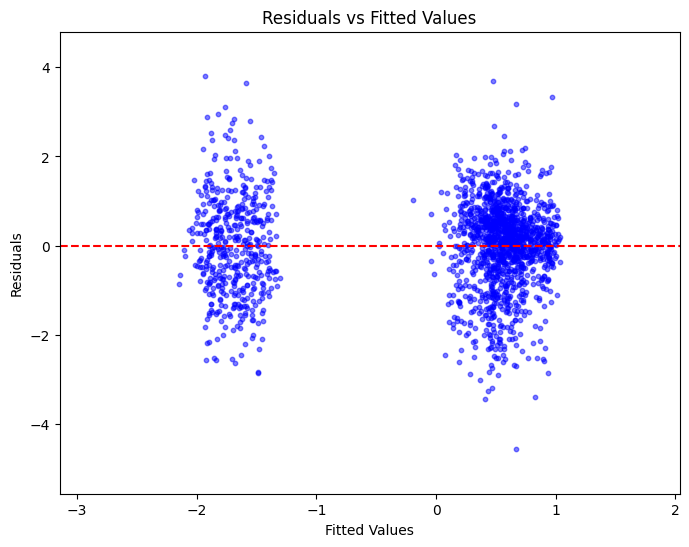

In [14]:
# Calculate residuals and fitted values
residuals = model.resid.dropna()
fitted_values = model.fittedvalues.dropna()

# Standardize if necessary (optional)
residuals = (residuals - residuals.mean()) / residuals.std()
fitted_values = (fitted_values - fitted_values.mean()) / fitted_values.std()

# Plot residuals vs fitted values
plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, residuals, color='blue', alpha=0.5, s=10)  # Adjust marker size
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

# Manually set axis limits to avoid empty space
plt.xlim(fitted_values.min() - 1, fitted_values.max() + 1)
plt.ylim(residuals.min() - 1, residuals.max() + 1)

# Show the plot
plt.show()

The residuals are randomly scattered about the zero line.

The separate cluster of points is caused by the inclusion of the categorical variables `cluster_type`, as such it is not an issue with the linear model.

Therefore, the constant variance assumption is met.

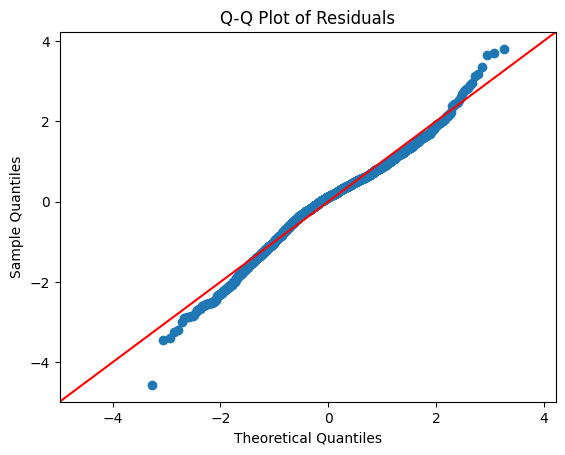

In [15]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Q-Q plot of residuals
sm.qqplot(model.resid, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

The QQ-plot of residuals lies along the straight line. 

At the left tail, only one point deviates from the straight line.

At the right tail, the points curves back to the straight line after some deviation.

As such, the residuals can still be considered as normally distributed.

# Econometrics Analysis Conclusion

At 5% level of significance, we observe that:
- p-value of num_edits is < 0.05
- p-value of num_edits_squared is < 0.05

The coefficient for `num_edits` is positive, whereas `num_edits_squared` is negative (with a smaller magnitude).

Therefore, we are able to conclude that on average, holding num_tracks and cluster_type constant, an increase in the number of edits is associated with an increase in relevance, but at a diminishing rate.

This suggests that, as users edit their playlists more, the recommendations become more relevant — but each additional edit contributes less than the one before. After a certain point, making more edits might not help further, and could even slightly reduce relevance.

# Business Decision Making

### Use of Insights to Improve Recommendation Quality and User Retention
In order to increase the quality of recommendations, the system could indirectly nudge users with low playlist edits to actively curate their playlists. This can be achieved through subtle UX cues, contextual prompts, or onboarding tips that highlight how editing can improve the personalization of their music experience.

### A/B Testing for Behavioral Interventions
To validate the impact of such interventions, A/B testing could be conducted. This would involve:
- Control Group: No nudges or minimal editing suggestions.
- Treatment Group(s): Exposure to various types of editing nudges (e.g., tooltips, banners, smart suggestions).

Aiming to measure:
- User retention 
- Session length and return frequency
- Perceived recommendation quality 

Additionally, the analysis can explore whether there's a significant difference in retention and satisfaction between high-edit and low-edit users, both before and after nudging.